# 04 - Inference Pipeline Test

**RAPP Lab 04 - Temporal Ensemble for Smooth Robot Control**

This notebook validates the real-time inference pipeline offline by replaying test episodes:

1. **Setup:** Load model, normalization stats, and test data
2. **Pipeline Test:** Replay episode frame-by-frame through InputAssembler → ModelWrapper → TemporalEnsemble → SafetyChecker
3. **Ensemble Visualization:** Raw chunk predictions vs temporal ensemble output vs ground truth
4. **Smoothness Comparison:** Velocity/acceleration profiles
5. **Parameter Sweep:** Vary K and λ, plot RMSE vs smoothness tradeoff
6. **Latency Profiling:** Measure inference timing

---

**Input:** Trained model checkpoint + preprocessed data tensors  
**Output:** Validated inference pipeline + optimal ensemble parameters  
**Dependencies:** No ROS2 required — runs entirely in Jupyter

## 1. Setup

In [7]:
import sys
import time
from pathlib import Path

workspace_dir = Path('/workspace')
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from vam_utils.config import InferenceConfig, ModelConfig
from vam_utils.config.data_config import DataPipelineConfig
from vam_utils.data import NormalizationStats, inverse_normalize_joints
from vam_utils.inference import (
    InputAssembler,
    VAMModelWrapper,
    TemporalEnsemble,
    SafetyChecker,
)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name()}')

print('\nImports successful!')

Device: cuda
  GPU: NVIDIA GeForce RTX 5090

Imports successful!


## 2. Load Model & Data

In [8]:
# =============================================================================
# CONFIGURATION — Point to your trained model and data
# =============================================================================
DATA_DIR = Path('/data/processed/tensors/2026_02_10_tin10_tout10')

inference_config = InferenceConfig(
    checkpoint_path=Path('/data/models/vam_20260210_2342/best.pt'),
    model_config_path=Path('/data/models/vam_20260210_2342/model_config.json'),
    norm_stats_path=DATA_DIR / 'norm_stats.pt',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    prediction_stride_K=2,
    ensemble_decay_weight=0.01,
    control_rate_hz=15.0,
    max_joint_velocity_rad_s=1.0,
    max_joint_acceleration_rad_s2=5.0,
)
# =============================================================================

print('Inference Configuration')
print('=' * 60)
print(f'  Checkpoint:       {inference_config.checkpoint_path}')
print(f'  Device:           {inference_config.device}')
print(f'  Prediction K:     {inference_config.prediction_stride_K}')
print(f'  Decay weight:     {inference_config.ensemble_decay_weight}')
print(f'  Control rate:     {inference_config.control_rate_hz} Hz')
print(f'  Max velocity:     {inference_config.max_joint_velocity_rad_s} rad/s')
print(f'  Max acceleration: {inference_config.max_joint_acceleration_rad_s2} rad/s^2')
print(f'  Ensemble history: {inference_config.max_ensemble_history} chunks')
print(f'  Warmup frames:    {inference_config.warmup_frames}')

Inference Configuration
  Checkpoint:       /data/models/vam_20260210_2342/best.pt
  Device:           cuda
  Prediction K:     2
  Decay weight:     0.01
  Control rate:     15.0 Hz
  Max velocity:     1.0 rad/s
  Max acceleration: 5.0 rad/s^2
  Ensemble history: 5 chunks
  Warmup frames:    20


In [9]:
# Load the model wrapper
model = VAMModelWrapper(inference_config)

# Load normalization stats (also used by model internally)
norm_stats = NormalizationStats.load(inference_config.norm_stats_path)

# Load data pipeline config
data_config = DataPipelineConfig.load(DATA_DIR / 'pipeline_config.json')
T_in = data_config.T_in
T_out = data_config.T_out

print(f'\nModel loaded successfully')
print(f'T_in={T_in}, T_out={T_out}')


Model loaded successfully
T_in=10, T_out=10


In [10]:
# Load episode tensors and split info
episode_data = {}
ep_dir = DATA_DIR / 'episodes'
for ep_file in sorted(ep_dir.glob('*.pt')):
    ep_id = ep_file.stem
    episode_data[ep_id] = torch.load(ep_file, weights_only=False)
print(f'Loaded {len(episode_data)} episodes')

with open(DATA_DIR / 'splits.json') as f:
    splits_dict = json.load(f)
print(f'Test episodes: {splits_dict["test"]}')

# Pick first test episode for detailed analysis
test_ep_id = splits_dict['test'][0]
test_ep = episode_data[test_ep_id]
n_frames = test_ep['skeleton'].shape[0]
print(f'\nUsing test episode: {test_ep_id}')
print(f'  Frames: {n_frames}')
print(f'  Skeleton: {test_ep["skeleton"].shape}')
print(f'  Joints:   {test_ep["joints"].shape}')

Loaded 10 episodes
Test episodes: ['25_12_11_RAPP_M_R2G1S1_02', '25_12_11_RAPP_M_R2G5S1_01']

Using test episode: 25_12_11_RAPP_M_R2G1S1_02
  Frames: 1191
  Skeleton: (1191, 48)
  Joints:   (1191, 6)


## 3. Full Pipeline Simulation

Replay the test episode frame-by-frame through the complete inference pipeline:

```
CSV frame → InputAssembler → ModelWrapper → TemporalEnsemble → SafetyChecker → output
```

This simulates exactly what would happen in the ROS2 node, but using saved data.

In [11]:
def run_inference_pipeline(
    episode_data_dict,
    model_wrapper,
    norm_stats,
    K=2,
    decay_weight=0.01,
    max_vel=1.0,
    max_acc=5.0,
    dt=1/15.0,
    T_in=10,
    T_out=10,
    collect_raw_chunks=False,
):
    """
    Run the full inference pipeline on a single episode.
    
    Returns dict with:
        ensemble_trajectory: [N, 6] blended joint angles (radians)
        gt_trajectory: [N, 6] ground truth joints (radians)
        safety_warnings: list of warning strings
        n_predictions: total model calls
        n_constrained: frames where safety checker intervened
        raw_chunks: (optional) list of (step, chunk) for visualization
    """
    skeleton_raw = episode_data_dict['skeleton']
    joints_raw = episode_data_dict['joints']
    # Handle both torch tensors and numpy arrays
    skeleton = skeleton_raw.numpy() if hasattr(skeleton_raw, 'numpy') else np.asarray(skeleton_raw)
    joints = joints_raw.numpy() if hasattr(joints_raw, 'numpy') else np.asarray(joints_raw)
    n_frames = skeleton.shape[0]
    
    assembler = InputAssembler(norm_stats, T_in=T_in)
    ensemble = TemporalEnsemble(T_out=T_out, K=K, decay_weight=decay_weight)
    safety = SafetyChecker(
        max_joint_velocity_rad_s=max_vel,
        max_joint_acceleration_rad_s2=max_acc,
        dt=dt,
    )
    
    ensemble_out = []
    gt_out = []
    all_warnings = []
    n_predictions = 0
    n_constrained = 0
    raw_chunks = [] if collect_raw_chunks else None
    
    for i in range(n_frames):
        # Feed frame to assembler
        assembler.add_frame(skeleton[i], joints[i])
        
        if not assembler.is_ready():
            continue
        
        # Should we predict?
        if ensemble.should_predict():
            input_tensor = assembler.get_input_tensor()
            chunk = model_wrapper.predict(input_tensor)  # [T_out, 6] radians
            ensemble.add_prediction(chunk)
            n_predictions += 1
            if collect_raw_chunks:
                raw_chunks.append((ensemble.global_step, chunk.copy()))
        
        # Query blended target
        if ensemble.num_predictions > 0:
            target = ensemble.query()
            report = safety.check(target)
            ensemble_out.append(report.target)
            
            # Ground truth: the joint values T_out frames ahead (if available)
            gt_idx = i + T_out
            if gt_idx < n_frames:
                gt_out.append(joints[gt_idx])
            else:
                gt_out.append(joints[-1])  # clamp to last frame
            
            if report.warnings:
                all_warnings.extend(report.warnings)
            if report.was_constrained:
                n_constrained += 1
        
        ensemble.step()
    
    return {
        'ensemble_trajectory': np.array(ensemble_out),
        'gt_trajectory': np.array(gt_out),
        'safety_warnings': all_warnings,
        'n_predictions': n_predictions,
        'n_constrained': n_constrained,
        'raw_chunks': raw_chunks,
    }

In [12]:
# Run with default parameters (K=2, lambda=0.01)
print(f'Running pipeline on episode {test_ep_id} ({n_frames} frames)...')
print(f'  K={inference_config.prediction_stride_K}, lambda={inference_config.ensemble_decay_weight}')

t_start = time.perf_counter()
results = run_inference_pipeline(
    test_ep,
    model,
    norm_stats,
    K=inference_config.prediction_stride_K,
    decay_weight=inference_config.ensemble_decay_weight,
    max_vel=inference_config.max_joint_velocity_rad_s,
    max_acc=inference_config.max_joint_acceleration_rad_s2,
    collect_raw_chunks=True,
)
t_elapsed = time.perf_counter() - t_start

print(f'\nPipeline complete in {t_elapsed:.2f}s')
print(f'  Output frames:    {len(results["ensemble_trajectory"])}')
print(f'  Model predictions: {results["n_predictions"]}')
print(f'  Safety constrained: {results["n_constrained"]} frames')
if results['safety_warnings']:
    unique_warnings = set(w.split(':')[0] for w in results['safety_warnings'])
    print(f'  Warning types: {unique_warnings}')
    print(f'  Total warnings: {len(results["safety_warnings"])}')

Running pipeline on episode 25_12_11_RAPP_M_R2G1S1_02 (1191 frames)...
  K=2, lambda=0.01

Pipeline complete in 0.68s
  Output frames:    1182
  Model predictions: 591
  Safety constrained: 526 frames
  Warning types: {'Velocity limited', 'Acceleration limited'}
  Total warnings: 571


## 4. Ensemble vs Ground Truth Visualization

Compare the temporal ensemble output against ground truth joint trajectories.

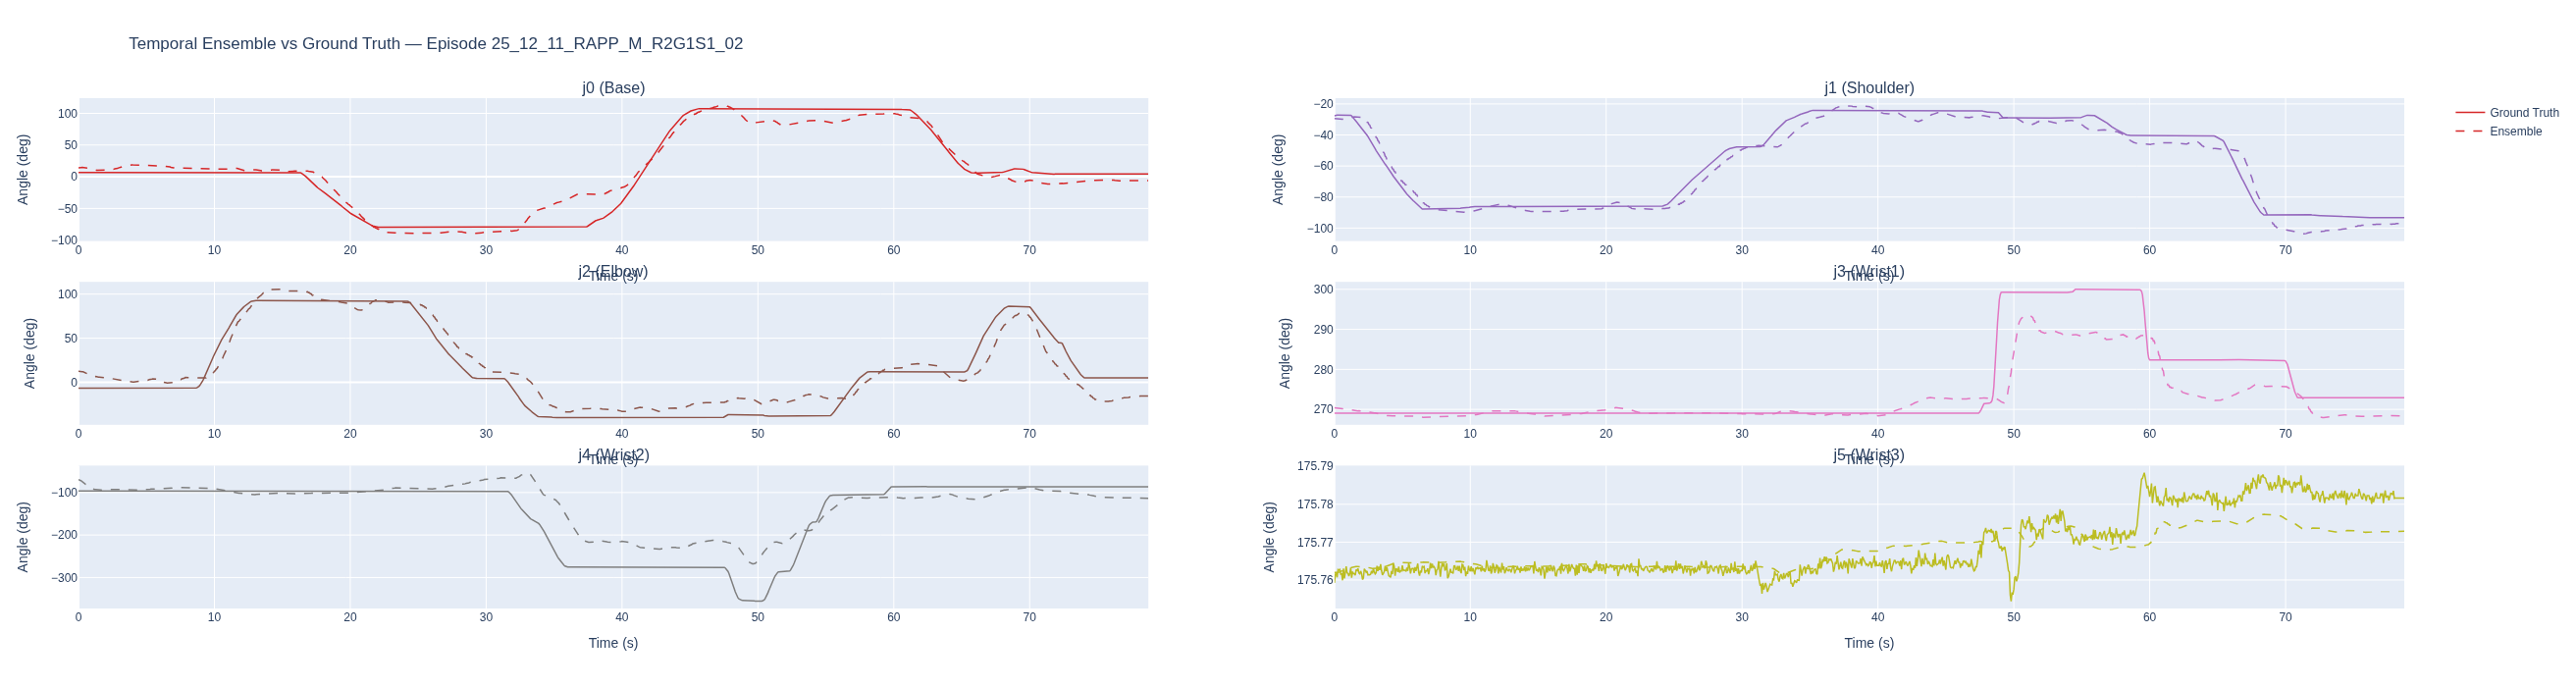


Per-joint RMSE (ensemble vs GT):
  j0 (Base): 15.79 deg (0.2756 rad)
  j1 (Shoulder): 5.53 deg (0.0965 rad)
  j2 (Elbow): 15.34 deg (0.2677 rad)
  j3 (Wrist1): 5.81 deg (0.1013 rad)
  j4 (Wrist2): 42.05 deg (0.7339 rad)
  j5 (Wrist3): 0.01 deg (0.0001 rad)


In [13]:
ensemble_traj = results['ensemble_trajectory']  # [N, 6] radians
gt_traj = results['gt_trajectory']              # [N, 6] radians

n_output = len(ensemble_traj)
time_axis = np.arange(n_output) / 15.0  # seconds

joint_names = ['j0 (Base)', 'j1 (Shoulder)', 'j2 (Elbow)', 
               'j3 (Wrist1)', 'j4 (Wrist2)', 'j5 (Wrist3)']
colors = ['#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=joint_names,
    horizontal_spacing=0.08,
    vertical_spacing=0.08,
)

for j in range(6):
    row, col = j // 2 + 1, j % 2 + 1
    
    # Ground truth
    fig.add_trace(go.Scatter(
        x=time_axis, y=np.degrees(gt_traj[:, j]),
        name='Ground Truth' if j == 0 else None,
        mode='lines', line=dict(color=colors[j], width=1.5),
        showlegend=(j == 0),
    ), row=row, col=col)
    
    # Ensemble prediction
    fig.add_trace(go.Scatter(
        x=time_axis, y=np.degrees(ensemble_traj[:, j]),
        name='Ensemble' if j == 0 else None,
        mode='lines', line=dict(color=colors[j], width=1.5, dash='dash'),
        showlegend=(j == 0),
    ), row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title_text=f'Temporal Ensemble vs Ground Truth — Episode {test_ep_id}',
)
fig.update_xaxes(title_text='Time (s)')
fig.update_yaxes(title_text='Angle (deg)')
fig.show()

# Per-joint RMSE
min_len = min(len(ensemble_traj), len(gt_traj))
rmse_per_joint = np.sqrt(((ensemble_traj[:min_len] - gt_traj[:min_len]) ** 2).mean(axis=0))
print('\nPer-joint RMSE (ensemble vs GT):')
for j, name in enumerate(joint_names):
    print(f'  {name}: {np.degrees(rmse_per_joint[j]):.2f} deg ({rmse_per_joint[j]:.4f} rad)')

## 5. Visualize Overlapping Chunks

Show how individual prediction chunks overlap and how the ensemble blends them.
This is the key insight: at each timestep, multiple chunks contribute, and the weighted average produces smooth output.

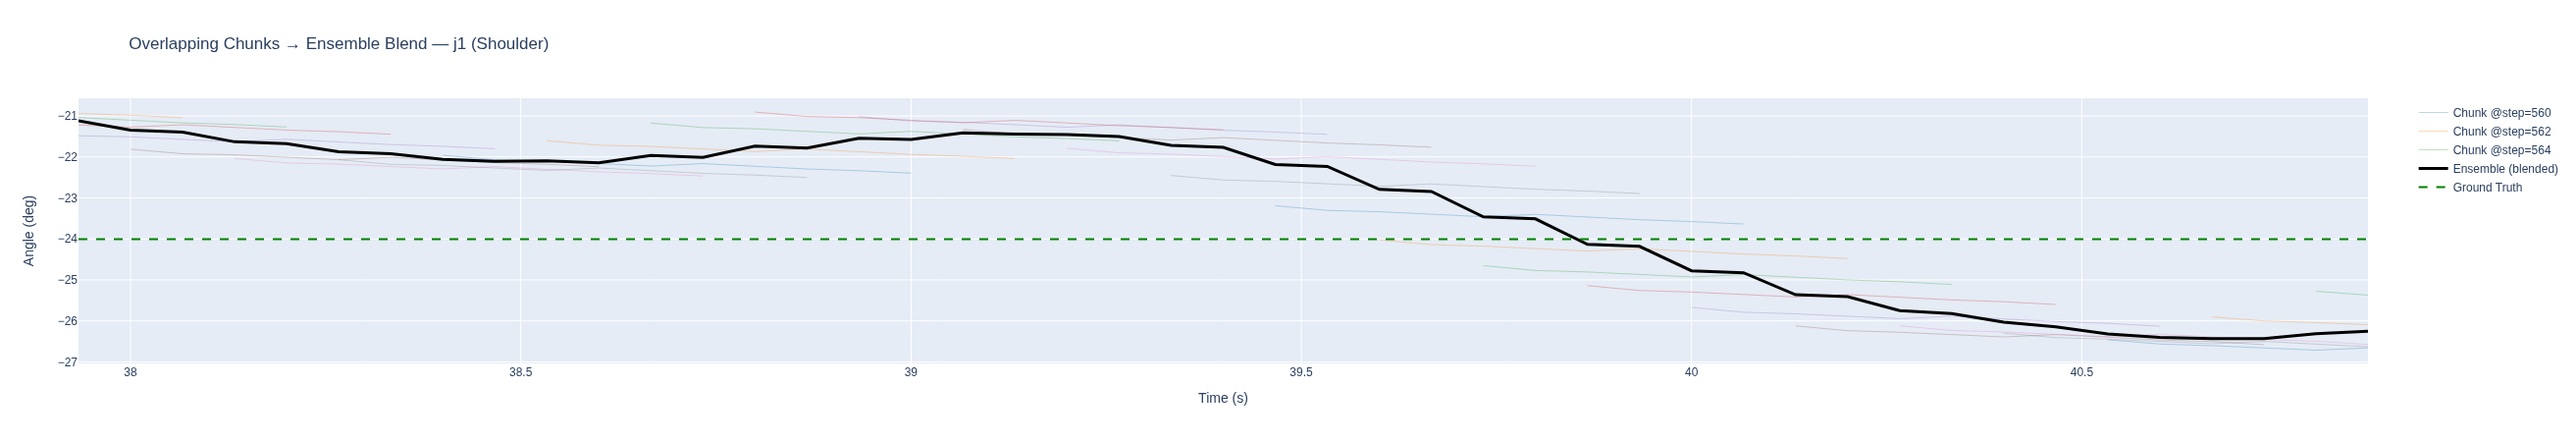

Showing 27 overlapping chunks in the window


In [14]:
# Visualize a 3-second window showing overlapping chunks for joint 1 (shoulder)
JOINT_IDX = 1  # shoulder — has clear motion and moderate error
raw_chunks = results['raw_chunks']
K = inference_config.prediction_stride_K

# Pick a window in the middle of the episode
mid_step = len(ensemble_traj) // 2
window_start = max(0, mid_step - 22)
window_end = min(len(ensemble_traj), mid_step + 23)

fig = go.Figure()

# Plot individual chunks as semi-transparent lines
chunk_colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)',
                'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)',
                'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)']

chunks_plotted = 0
for step, chunk in raw_chunks:
    chunk_start = step
    chunk_end = step + T_out
    # Only plot chunks that overlap with our window
    if chunk_end < window_start or chunk_start > window_end:
        continue
    
    t = np.arange(step, step + T_out) / 15.0
    # Filter to window
    mask = (np.arange(step, step + T_out) >= window_start) & (np.arange(step, step + T_out) < window_end)
    if not mask.any():
        continue
    
    color = chunk_colors[chunks_plotted % len(chunk_colors)]
    fig.add_trace(go.Scatter(
        x=t[mask], y=np.degrees(chunk[mask, JOINT_IDX]),
        mode='lines', line=dict(color=color, width=1),
        name=f'Chunk @step={step}' if chunks_plotted < 3 else None,
        showlegend=(chunks_plotted < 3),
    ))
    chunks_plotted += 1

# Ensemble output (bold)
t_ensemble = np.arange(window_start, min(window_end, len(ensemble_traj))) / 15.0
fig.add_trace(go.Scatter(
    x=t_ensemble, y=np.degrees(ensemble_traj[window_start:window_end, JOINT_IDX]),
    mode='lines', line=dict(color='black', width=3),
    name='Ensemble (blended)',
))

# Ground truth
fig.add_trace(go.Scatter(
    x=t_ensemble, y=np.degrees(gt_traj[window_start:window_end, JOINT_IDX]),
    mode='lines', line=dict(color='green', width=2, dash='dash'),
    name='Ground Truth',
))

fig.update_layout(
    title=f'Overlapping Chunks → Ensemble Blend — {joint_names[JOINT_IDX]}',
    xaxis_title='Time (s)', yaxis_title='Angle (deg)',
    height=450, width=1000,
)
fig.show()
print(f'Showing {chunks_plotted} overlapping chunks in the window')

## 6. Smoothness Analysis

Compare velocity and acceleration profiles of ensemble output vs ground truth.
The ensemble should produce smooth velocity (no spikes at chunk boundaries).

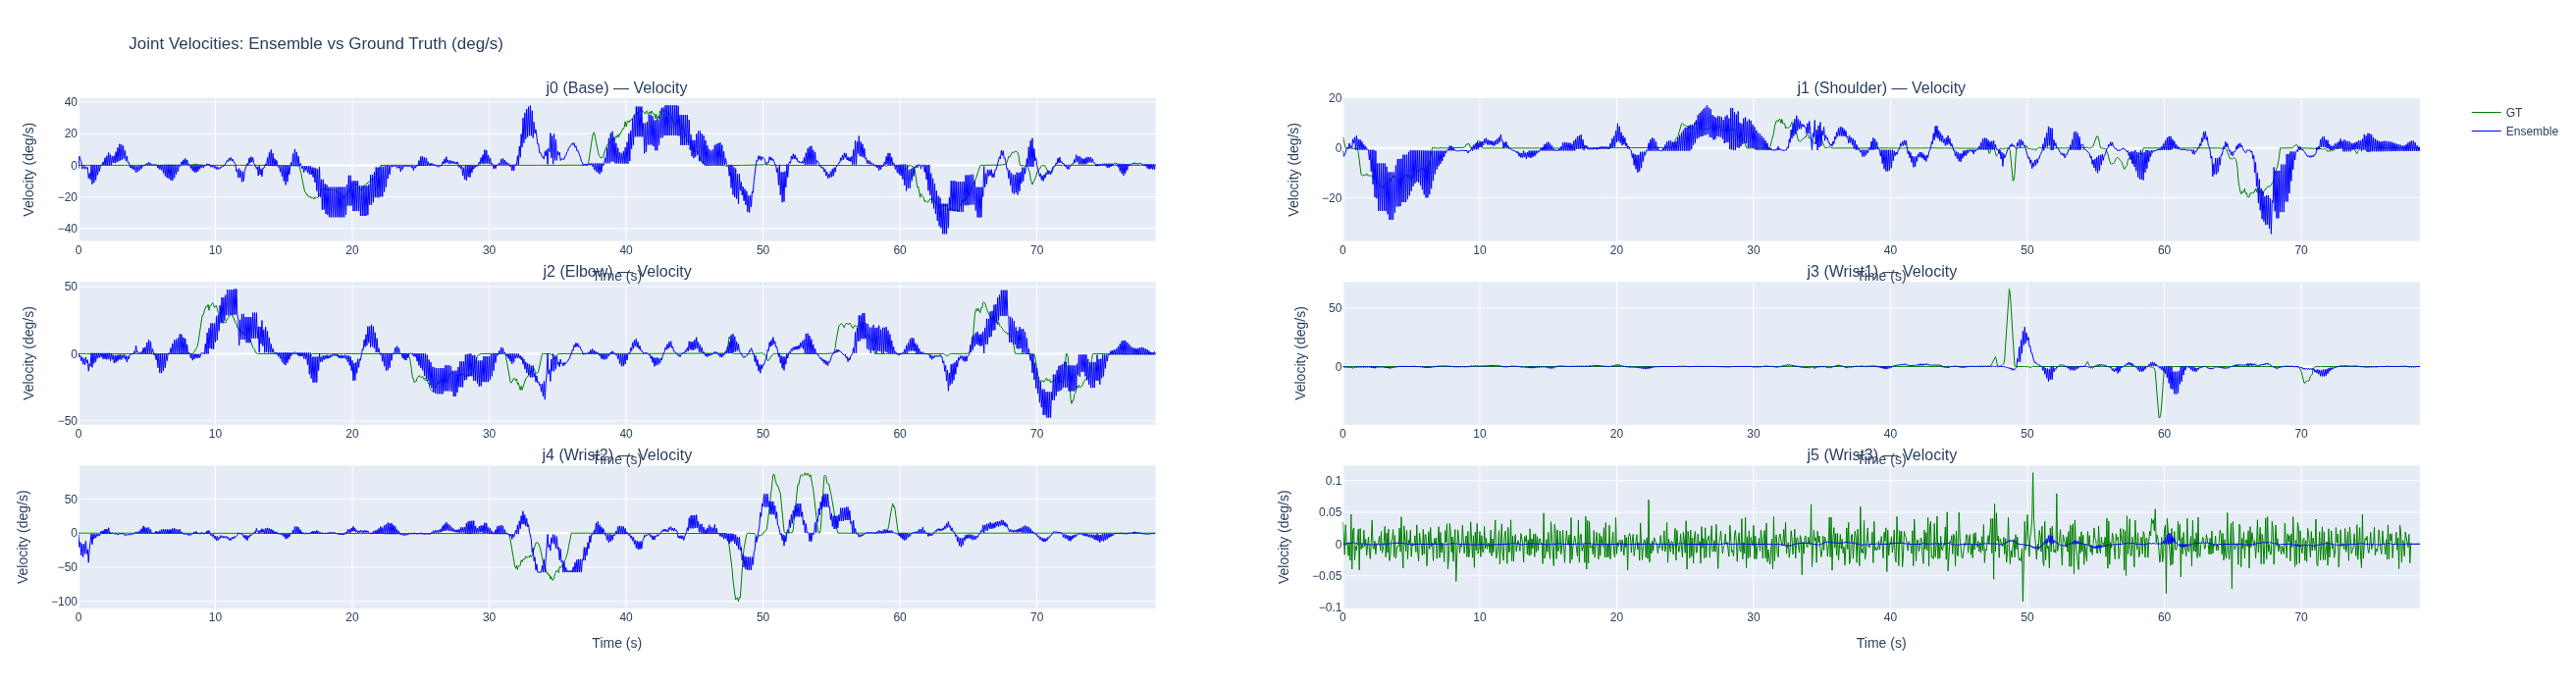


Smoothness Metrics (lower = smoother):
                       Ensemble           GT
---------------------------------------------
j0 (Base)                 148.7         12.9 deg/s^2 (std of acc)
j1 (Shoulder)              98.8          9.9 deg/s^2 (std of acc)
j2 (Elbow)                160.4         21.1 deg/s^2 (std of acc)
j3 (Wrist1)                43.1         22.5 deg/s^2 (std of acc)
j4 (Wrist2)               134.9         46.4 deg/s^2 (std of acc)
j5 (Wrist3)                 0.0          0.5 deg/s^2 (std of acc)


In [15]:
dt = 1.0 / 15.0  # seconds per frame

# Compute velocities (deg/s) and accelerations (deg/s^2)
ensemble_vel = np.diff(np.degrees(ensemble_traj), axis=0) / dt  # [N-1, 6]
gt_vel = np.diff(np.degrees(gt_traj), axis=0) / dt

ensemble_acc = np.diff(ensemble_vel, axis=0) / dt  # [N-2, 6]
gt_acc = np.diff(gt_vel, axis=0) / dt

t_vel = np.arange(len(ensemble_vel)) / 15.0
t_acc = np.arange(len(ensemble_acc)) / 15.0

# Plot velocity for each joint
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[f'{name} — Velocity' for name in joint_names],
    horizontal_spacing=0.08,
    vertical_spacing=0.08,
)

for j in range(6):
    row, col = j // 2 + 1, j % 2 + 1
    fig.add_trace(go.Scatter(
        x=t_vel, y=gt_vel[:, j],
        name='GT' if j == 0 else None,
        mode='lines', line=dict(color='green', width=1),
        showlegend=(j == 0),
    ), row=row, col=col)
    fig.add_trace(go.Scatter(
        x=t_vel, y=ensemble_vel[:, j],
        name='Ensemble' if j == 0 else None,
        mode='lines', line=dict(color='blue', width=1),
        showlegend=(j == 0),
    ), row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title_text='Joint Velocities: Ensemble vs Ground Truth (deg/s)',
)
fig.update_xaxes(title_text='Time (s)')
fig.update_yaxes(title_text='Velocity (deg/s)')
fig.show()

# Smoothness metrics
print('\nSmoothness Metrics (lower = smoother):')
print(f'{"":<18} {"Ensemble":>12} {"GT":>12}')
print('-' * 45)
for j, name in enumerate(joint_names):
    ens_jerk = np.std(ensemble_acc[:, j])
    gt_jerk = np.std(gt_acc[:, j])
    print(f'{name:<18} {ens_jerk:>12.1f} {gt_jerk:>12.1f} deg/s^2 (std of acc)')

## 7. Parameter Sweep

Vary K (prediction stride) and λ (decay weight) to find the optimal tradeoff
between tracking accuracy (RMSE) and smoothness (acceleration std).

In [16]:
K_values = [1, 2, 3, 5]
lambda_values = [0.01, 0.05, 0.1, 0.5]

sweep_results = []

print('Running parameter sweep...')
for K in K_values:
    for lam in lambda_values:
        res = run_inference_pipeline(
            test_ep, model, norm_stats,
            K=K, decay_weight=lam,
            max_vel=10.0,  # disable velocity limiting for fair comparison
            max_acc=100.0,  # disable acceleration limiting
        )
        
        ens = res['ensemble_trajectory']
        gt = res['gt_trajectory']
        min_len = min(len(ens), len(gt))
        
        # RMSE across all joints
        rmse = np.sqrt(((ens[:min_len] - gt[:min_len]) ** 2).mean())
        rmse_deg = np.degrees(rmse)
        
        # Smoothness: std of acceleration
        vel = np.diff(ens, axis=0) / dt
        acc = np.diff(vel, axis=0) / dt
        acc_std = np.std(acc)  # overall
        acc_std_deg = np.degrees(acc_std)
        
        sweep_results.append({
            'K': K, 'lambda': lam,
            'rmse_deg': rmse_deg,
            'acc_std_deg': acc_std_deg,
            'n_predictions': res['n_predictions'],
        })
        print(f'  K={K}, λ={lam:.2f} → RMSE={rmse_deg:.2f}° | Acc std={acc_std_deg:.1f}°/s² | {res["n_predictions"]} predictions')

print('\nSweep complete!')

Running parameter sweep...
  K=1, λ=0.01 → RMSE=19.60° | Acc std=15.1°/s² | 1182 predictions
  K=1, λ=0.05 → RMSE=19.55° | Acc std=15.1°/s² | 1182 predictions
  K=1, λ=0.10 → RMSE=19.49° | Acc std=15.4°/s² | 1182 predictions
  K=1, λ=0.50 → RMSE=19.23° | Acc std=22.7°/s² | 1182 predictions
  K=2, λ=0.01 → RMSE=19.60° | Acc std=267.4°/s² | 591 predictions
  K=2, λ=0.05 → RMSE=19.56° | Acc std=267.7°/s² | 591 predictions
  K=2, λ=0.10 → RMSE=19.50° | Acc std=268.4°/s² | 591 predictions
  K=2, λ=0.50 → RMSE=19.24° | Acc std=279.4°/s² | 591 predictions
  K=3, λ=0.01 → RMSE=19.54° | Acc std=333.3°/s² | 394 predictions
  K=3, λ=0.05 → RMSE=19.51° | Acc std=333.0°/s² | 394 predictions
  K=3, λ=0.10 → RMSE=19.47° | Acc std=333.1°/s² | 394 predictions
  K=3, λ=0.50 → RMSE=19.27° | Acc std=342.0°/s² | 394 predictions
  K=5, λ=0.01 → RMSE=19.62° | Acc std=424.2°/s² | 237 predictions
  K=5, λ=0.05 → RMSE=19.59° | Acc std=424.4°/s² | 237 predictions
  K=5, λ=0.10 → RMSE=19.54° | Acc std=425.3°/s² |

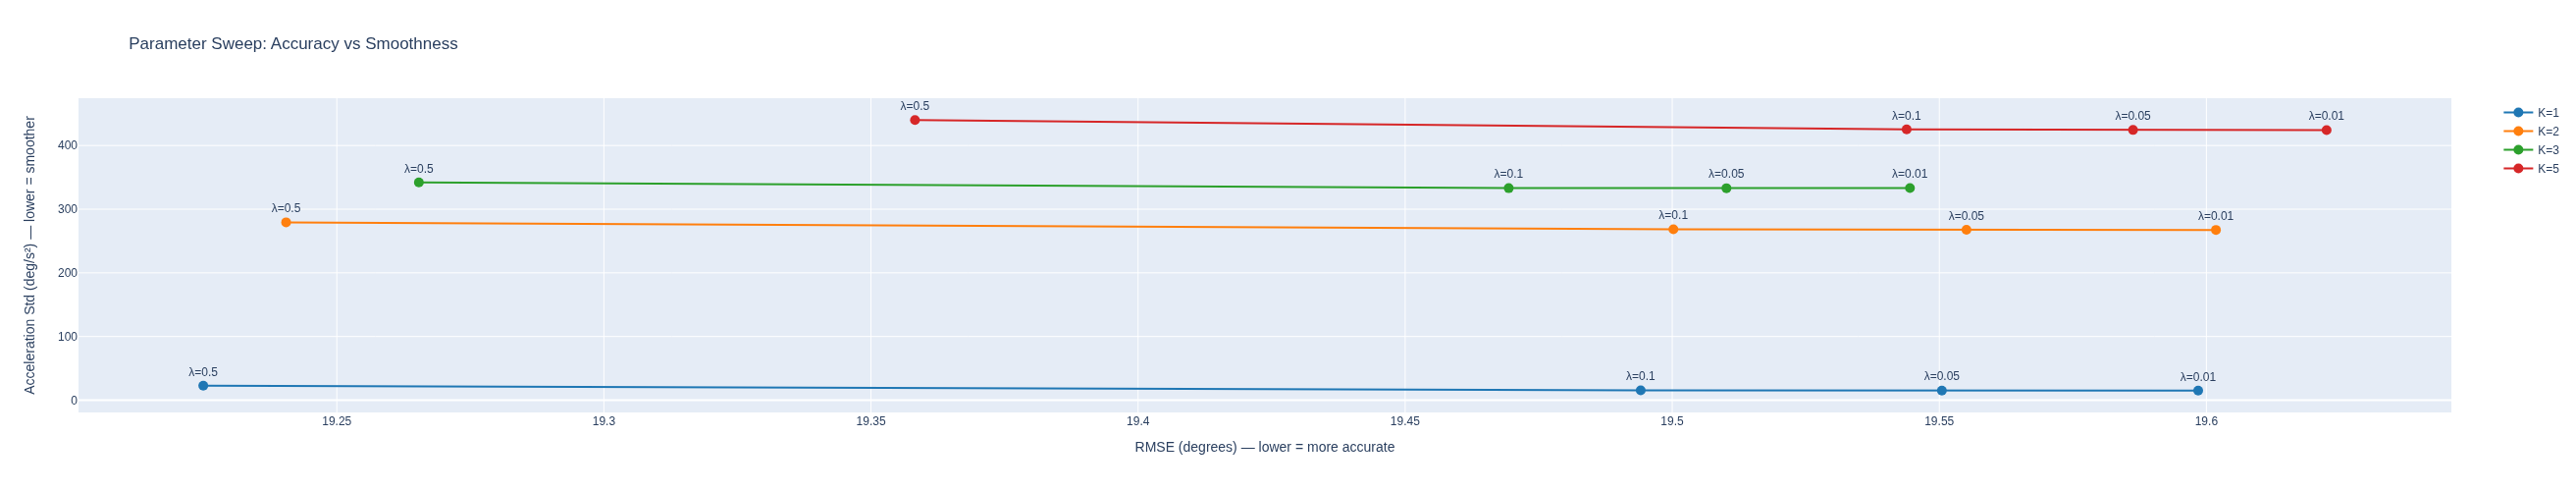


All results sorted by RMSE:
  K      λ   RMSE (deg)      Acc std  Predictions
--------------------------------------------------
  1   0.50        19.23         22.7         1182
  2   0.50        19.24        279.4          591
  3   0.50        19.27        342.0          394
  5   0.50        19.36        440.0          237
  3   0.10        19.47        333.1          394
  1   0.10        19.49         15.4         1182
  2   0.10        19.50        268.4          591
  3   0.05        19.51        333.0          394
  5   0.10        19.54        425.3          237
  3   0.01        19.54        333.3          394
  1   0.05        19.55         15.1         1182
  2   0.05        19.56        267.7          591
  5   0.05        19.59        424.4          237
  1   0.01        19.60         15.1         1182
  2   0.01        19.60        267.4          591
  5   0.01        19.62        424.2          237


In [17]:
# Plot RMSE vs Smoothness tradeoff
fig = go.Figure()

k_colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 5: '#d62728'}

for K in K_values:
    subset = [r for r in sweep_results if r['K'] == K]
    fig.add_trace(go.Scatter(
        x=[r['rmse_deg'] for r in subset],
        y=[r['acc_std_deg'] for r in subset],
        mode='lines+markers+text',
        name=f'K={K}',
        marker=dict(size=10, color=k_colors[K]),
        text=[f'λ={r["lambda"]}' for r in subset],
        textposition='top center',
    ))

fig.update_layout(
    title='Parameter Sweep: Accuracy vs Smoothness',
    xaxis_title='RMSE (degrees) — lower = more accurate',
    yaxis_title='Acceleration Std (deg/s²) — lower = smoother',
    height=500, width=700,
)
fig.show()

# Find Pareto-optimal points
print('\nAll results sorted by RMSE:')
print(f'{"K":>3} {"λ":>6} {"RMSE (deg)":>12} {"Acc std":>12} {"Predictions":>12}')
print('-' * 50)
for r in sorted(sweep_results, key=lambda x: x['rmse_deg']):
    print(f'{r["K"]:>3} {r["lambda"]:>6.2f} {r["rmse_deg"]:>12.2f} {r["acc_std_deg"]:>12.1f} {r["n_predictions"]:>12}')

## 8. Latency Profiling

Measure inference timing to confirm we can run at 15Hz+ real-time.

In [18]:
# Build a test input
assembler = InputAssembler(norm_stats, T_in=T_in)
skeleton_raw = test_ep['skeleton']
joints_raw = test_ep['joints']
skeleton = skeleton_raw.numpy() if hasattr(skeleton_raw, 'numpy') else np.asarray(skeleton_raw)
joints = joints_raw.numpy() if hasattr(joints_raw, 'numpy') else np.asarray(joints_raw)
for i in range(T_in):
    assembler.add_frame(skeleton[i], joints[i])
test_input = assembler.get_input_tensor()

# Warmup
for _ in range(10):
    _ = model.predict(test_input)

# Profile
N_RUNS = 1000
if torch.cuda.is_available():
    torch.cuda.synchronize()

latencies = []
for _ in range(N_RUNS):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = model.predict(test_input)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latencies.append((time.perf_counter() - t0) * 1000)  # ms

latencies = np.array(latencies)

print(f'Inference Latency ({N_RUNS} runs)')
print('=' * 40)
print(f'  Mean:   {latencies.mean():.2f} ms')
print(f'  Median: {np.median(latencies):.2f} ms')
print(f'  P95:    {np.percentile(latencies, 95):.2f} ms')
print(f'  P99:    {np.percentile(latencies, 99):.2f} ms')
print(f'  Max:    {latencies.max():.2f} ms')
print(f'\n  Budget at 15Hz: 66.7 ms per frame')
print(f'  Headroom: {66.7 - latencies.mean():.1f} ms ({(1 - latencies.mean()/66.7)*100:.0f}%)')
print(f'  Max achievable rate: {1000/latencies.mean():.0f} Hz')

Inference Latency (1000 runs)
  Mean:   0.74 ms
  Median: 0.73 ms
  P95:    0.76 ms
  P99:    0.85 ms
  Max:    1.07 ms

  Budget at 15Hz: 66.7 ms per frame
  Headroom: 66.0 ms (99%)
  Max achievable rate: 1352 Hz


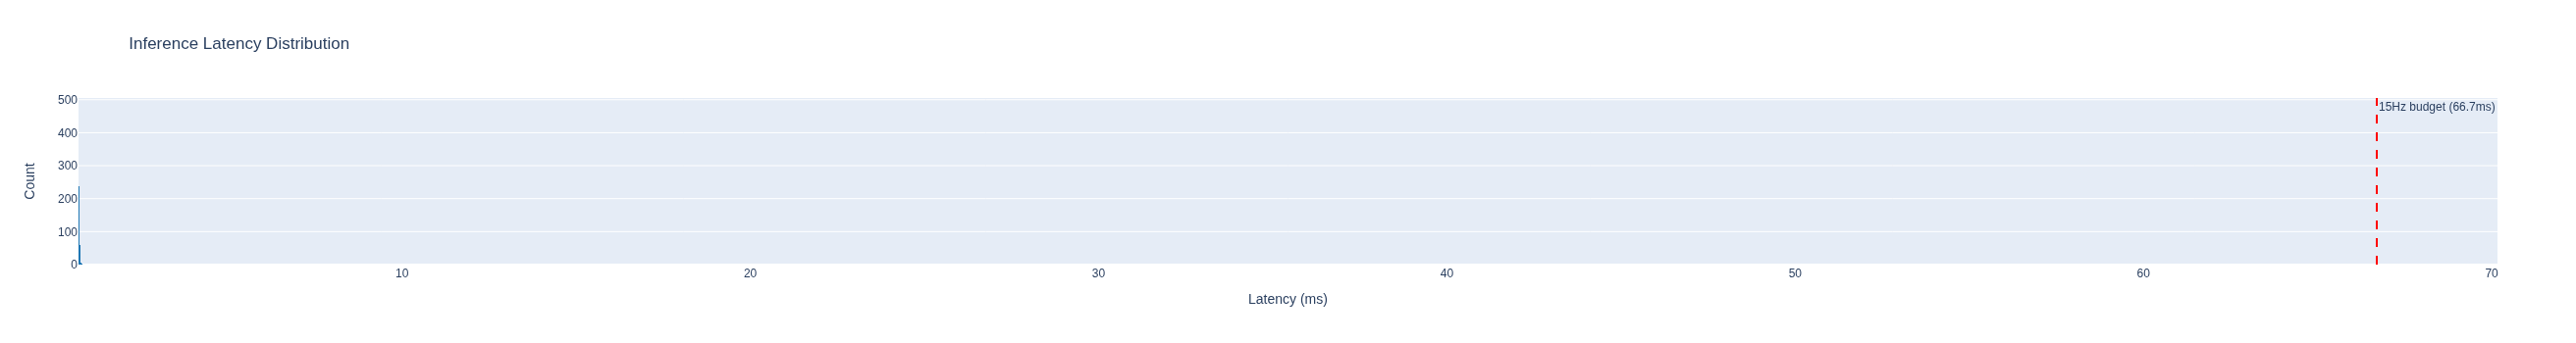

In [19]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=latencies, nbinsx=50,
    name='Inference latency',
    marker_color='#1f77b4',
))
fig.add_vline(x=66.7, line_dash='dash', line_color='red', 
              annotation_text='15Hz budget (66.7ms)')
fig.update_layout(
    title='Inference Latency Distribution',
    xaxis_title='Latency (ms)',
    yaxis_title='Count',
    height=350, width=600,
)
fig.show()

## 9. Summary

In [20]:
print('=' * 70)
print('INFERENCE PIPELINE TEST COMPLETE')
print('=' * 70)

print(f'\nEpisode: {test_ep_id} ({n_frames} frames)')

print(f'\nDefault Parameters:')
print(f'  K (stride):       {inference_config.prediction_stride_K}')
print(f'  Lambda (decay):   {inference_config.ensemble_decay_weight}')
print(f'  Control rate:     {inference_config.control_rate_hz} Hz')

print(f'\nPipeline Results:')
print(f'  Output frames:    {len(results["ensemble_trajectory"])}')
print(f'  Model calls:      {results["n_predictions"]}')
print(f'  Safety constrained: {results["n_constrained"]} frames')

print(f'\nAccuracy (ensemble vs GT):')
for j, name in enumerate(joint_names):
    print(f'  {name}: {np.degrees(rmse_per_joint[j]):.2f} deg')

print(f'\nInference Latency:')
print(f'  Mean: {latencies.mean():.2f} ms')
print(f'  Max achievable rate: {1000/latencies.mean():.0f} Hz')

print(f'\n{"=" * 70}')
print('NEXT: Run this pipeline as a ROS2 node (Phase C) for live testing.')
print('  - Rosbag playback + RViz visualization')
print('  - Live skeleton tracking + RViz robot')
print('  - Physical robot at conservative velocity')
print('=' * 70)

INFERENCE PIPELINE TEST COMPLETE

Episode: 25_12_11_RAPP_M_R2G1S1_02 (1191 frames)

Default Parameters:
  K (stride):       2
  Lambda (decay):   0.01
  Control rate:     15.0 Hz

Pipeline Results:
  Output frames:    1182
  Model calls:      591
  Safety constrained: 526 frames

Accuracy (ensemble vs GT):
  j0 (Base): 15.79 deg
  j1 (Shoulder): 5.53 deg
  j2 (Elbow): 15.34 deg
  j3 (Wrist1): 5.81 deg
  j4 (Wrist2): 42.05 deg
  j5 (Wrist3): 0.01 deg

Inference Latency:
  Mean: 0.74 ms
  Max achievable rate: 1352 Hz

NEXT: Run this pipeline as a ROS2 node (Phase C) for live testing.
  - Rosbag playback + RViz visualization
  - Live skeleton tracking + RViz robot
  - Physical robot at conservative velocity
